# Rapido: Intelligent Mobility Insights
## Exploratory Data Analysis

Ride patterns, cancellations and fare forecasting across 100,000 bookings in five cities.

This notebook calls the project package directly (`rapido.*`) rather than reimplementing
logic, so every figure here matches the dashboard and the models.

**Contents**
1. Load and profile
2. Data quality and the leakage checks
3. Univariate analysis
4. Bivariate analysis - what drives cancellations
5. Multivariate analysis
6. Statistical significance
7. Fare structure
8. Feature engineering
9. Conclusions

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import config
from rapido import cleaning, features, io, stats

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)

print("Project:", config.BASE_DIR.name)

Project: Project_3


## 1. Load and Profile

In [2]:
raw = io.load_all_raw()
for name, frame in raw.items():
    print(f"{name:<18} {frame.shape[0]:>7,} rows x {frame.shape[1]:>2} columns")

bookings           100,000 rows x 22 columns
customers           10,000 rows x 13 columns
drivers              5,000 rows x 14 columns
location_demand     17,941 rows x 10 columns
time_features        8,760 rows x  7 columns


In [3]:
raw["bookings"].head()

,booking_id,booking_date,booking_time,day_of_week,is_weekend,hour_of_day,city,pickup_location,drop_location,vehicle_type,ride_distance_km,estimated_ride_time_min,actual_ride_time_min,traffic_level,weather_condition,base_fare,surge_multiplier,booking_value,booking_status,incomplete_ride_reason,customer_id,driver_id
0,B_000001,2025-12-11,00:07:00,Thursday,0,0,Mumbai,Loc_19,Loc_16,Bike,7.01,46.30,NaN,High,Heavy Rain,76.12,2.0,148.22,Cancelled,NaN,C_005097,D_004592
1,B_000002,2025-07-07,06:13:00,Monday,0,6,Mumbai,Loc_32,Loc_38,Cab,9.67,43.54,42.28,Medium,Heavy Rain,254.15,1.8,465.85,Completed,NaN,C_008459,D_000148
2,B_000003,2025-08-23,08:53:00,Saturday,1,8,Chennai,Loc_28,Loc_1,Auto,16.18,48.55,NaN,Low,Heavy Rain,234.20,1.9,457.03,Cancelled,NaN,C_003471,D_004976
3,B_000004,2025-04-12,10:25:00,Saturday,1,10,Delhi,Loc_16,Loc_30,Bike,1.02,4.61,4.76,Medium,Rain,28.20,1.8,51.03,Completed,NaN,C_002161,D_001173
4,B_000005,2025-08-23,00:08:00,Saturday,1,0,Hyderabad,Loc_22,Loc_31,Bike,12.35,55.56,64.53,Medium,Clear,118.77,1.2,144.73,Completed,NaN,C_005617,D_001175


In [4]:
profile = io.profile_dataframe(raw["bookings"], "bookings")
profile[["column", "dtype", "nulls", "null_pct", "unique"]]

,column,dtype,nulls,null_pct,unique
0,booking_id,string,0,0.00,100000
1,booking_date,str,0,0.00,365
2,booking_time,str,0,0.00,1440
3,day_of_week,category,0,0.00,7
4,is_weekend,int64,0,0.00,2
5,hour_of_day,int64,0,0.00,24
6,city,category,0,0.00,5
7,pickup_location,str,0,0.00,50
8,drop_location,str,0,0.00,50
9,vehicle_type,category,0,0.00,3


## 2. Data Quality and Leakage Checks

Three checks decide how the whole project is built.

### 2.1 Missingness is structural, not random

`actual_ride_time_min` is null for **exactly** the non-Completed rides. Its null
indicator alone reproduces the target, so it can never be a model feature.

In [5]:
bookings = raw["bookings"]
check = bookings.groupby("booking_status", observed=True).agg(
    rides=("booking_id", "count"),
    actual_time_null_rate=("actual_ride_time_min", lambda s: s.isna().mean()),
    reason_present_rate=("incomplete_ride_reason", lambda s: s.notna().mean()),
)
check

,rides,actual_time_null_rate,reason_present_rate
booking_status,,,
Cancelled,23284,1.0,0.0
Completed,68346,0.0,0.0
Incomplete,8370,1.0,1.0


### 2.2 Fare is a deterministic formula

`booking_value / (base_fare x surge_multiplier)` is confined to a narrow band, so
`base_fare` is excluded from the deployed fare model.

count    100000.000000
mean          0.999933
std           0.028904
min           0.949891
25%           0.974748
50%           1.000000
75%           1.024869
max           1.050034
dtype: float64


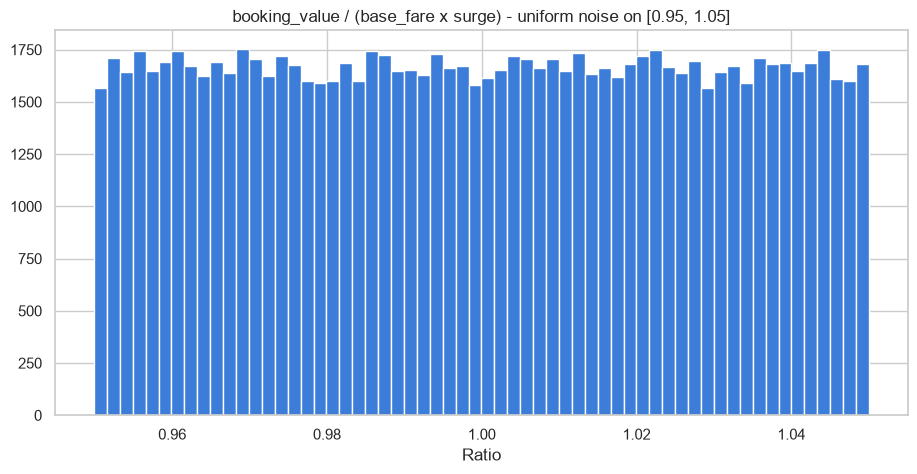

In [6]:
ratio = bookings["booking_value"] / (bookings["base_fare"] * bookings["surge_multiplier"])
print(ratio.describe())

fig, ax = plt.subplots()
ax.hist(ratio, bins=60, color="#3B7DD8", edgecolor="white")
ax.set_title("booking_value / (base_fare x surge) - uniform noise on [0.95, 1.05]")
ax.set_xlabel("Ratio")
plt.show()

### 2.3 The dimension risk flags are thresholds

`customer_cancel_flag` is exactly `cancellation_rate > 0.20` and `driver_delay_flag`
is exactly `delay_rate > 0.10`. Predicting a flag from its own rate is circular, so
the risk models target booking-level outcomes instead.

In [7]:
customers, drivers = raw["customers"], raw["drivers"]
print(customers.groupby("customer_cancel_flag")["cancellation_rate"].agg(["min", "max"]))
print()
print(drivers.groupby("driver_delay_flag")["delay_rate"].agg(["min", "max"]))

                           min  max
customer_cancel_flag               
0                     0.000000  0.2
1                     0.210526  1.0

                    min   max
driver_delay_flag            
0                  0.00  0.10
1                  0.11  0.42


## 3. Clean and Build Features

In [8]:
cleaned = cleaning.clean_all(raw)
summary = cleaning.build_cleaning_summary(raw, cleaned)
summary

,dataset,rows_before,rows_after,rows_removed,nulls_before,nulls_after,columns_after
0,bookings,100000,100000,0,123284,123284,23
1,customers,10000,10000,0,0,0,13
2,drivers,5000,5000,0,0,0,14
3,location_demand,17941,17941,0,0,0,11
4,time_features,8760,8760,0,0,0,7


In [9]:
df = features.build_feature_table(cleaned)
print(f"Feature table: {df.shape[0]:,} rows x {df.shape[1]} columns")
df[["booking_id", "booking_ts", "city", "vehicle_type", "ride_distance_km",
    "booking_value", "booking_status"]].head()

Feature table: 100,000 rows x 76 columns


,booking_id,booking_ts,city,vehicle_type,ride_distance_km,booking_value,booking_status
0,B_000001,2025-12-11 00:07:00,Mumbai,Bike,7.01,148.22,Cancelled
1,B_000002,2025-07-07 06:13:00,Mumbai,Cab,9.67,465.85,Completed
2,B_000003,2025-08-23 08:53:00,Chennai,Auto,16.18,457.03,Cancelled
3,B_000004,2025-04-12 10:25:00,Delhi,Bike,1.02,51.03,Completed
4,B_000005,2025-08-23 00:08:00,Hyderabad,Bike,12.35,144.73,Completed


## 4. Univariate Analysis

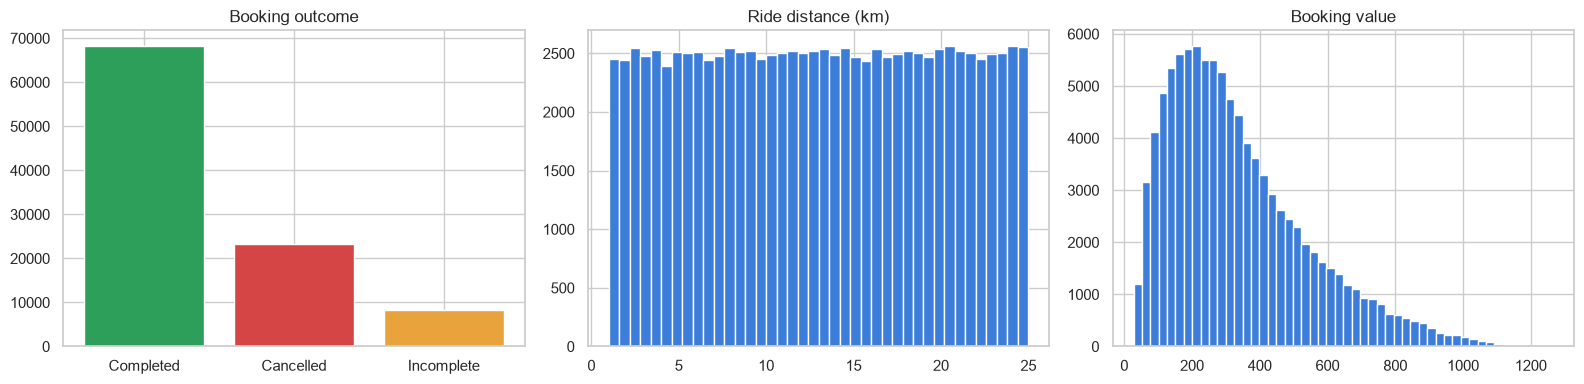

booking_status
Completed     0.6835
Cancelled     0.2328
Incomplete    0.0837
Name: proportion, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

status_counts = df["booking_status"].value_counts()
axes[0].bar(status_counts.index.astype(str), status_counts.values,
            color=["#2E9E5B", "#D64545", "#E8A33D"])
axes[0].set_title("Booking outcome")

axes[1].hist(df["ride_distance_km"], bins=40, color="#3B7DD8", edgecolor="white")
axes[1].set_title("Ride distance (km)")

axes[2].hist(df["booking_value"], bins=50, color="#3B7DD8", edgecolor="white")
axes[2].set_title("Booking value")

plt.tight_layout()
plt.show()

print(df["booking_status"].value_counts(normalize=True).round(4))

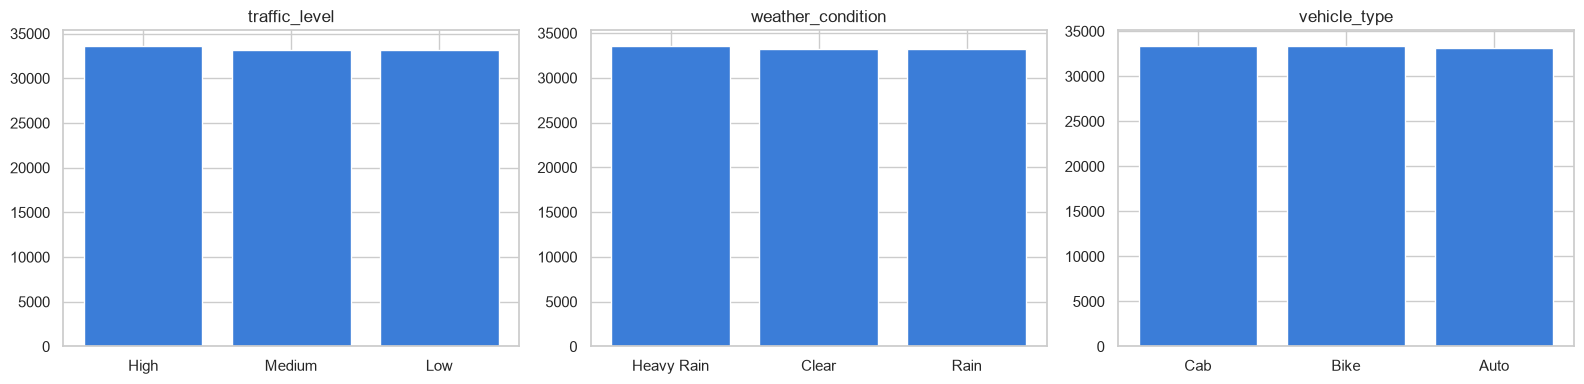

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, column in zip(axes, ["traffic_level", "weather_condition", "vehicle_type"]):
    counts = df[column].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color="#3B7DD8")
    ax.set_title(column)
plt.tight_layout()
plt.show()

## 5. Bivariate Analysis - What Drives Cancellations

In [12]:
for column in ["traffic_level", "weather_condition", "surge_bucket",
               "city", "vehicle_type", "rush_hour_flag"]:
    print(f"--- {column} ---")
    print(stats.cancellation_rate_by(df, column).to_string(index=False))
    print()

--- traffic_level ---
traffic_level  rides  cancel_rate  incomplete_rate
         High  33667        33.50            14.82
          Low  33135        18.26             5.14
       Medium  33198        17.93             5.05

--- weather_condition ---
weather_condition  rides  cancel_rate  incomplete_rate
       Heavy Rain  33616        33.67             8.40
             Rain  33184        26.04             8.43
            Clear  33200        10.01             8.28

--- surge_bucket ---
surge_bucket  rides  cancel_rate  incomplete_rate
        High   6434        35.25             9.70
      Medium  47856        34.15             9.70
         Low  37760        11.27             7.22
        None   7950         5.25             4.74

--- city ---
     city  rides  cancel_rate  incomplete_rate
   Mumbai  19943        23.78             8.29
    Delhi  20161        23.51             8.17
Hyderabad  19905        23.11             8.28
Bangalore  19947        23.06             8.45
  Chen

 rush_hour_flag  rides  cancel_rate  incomplete_rate
              1  28887        26.72             8.22
              0  71113        21.89             8.43



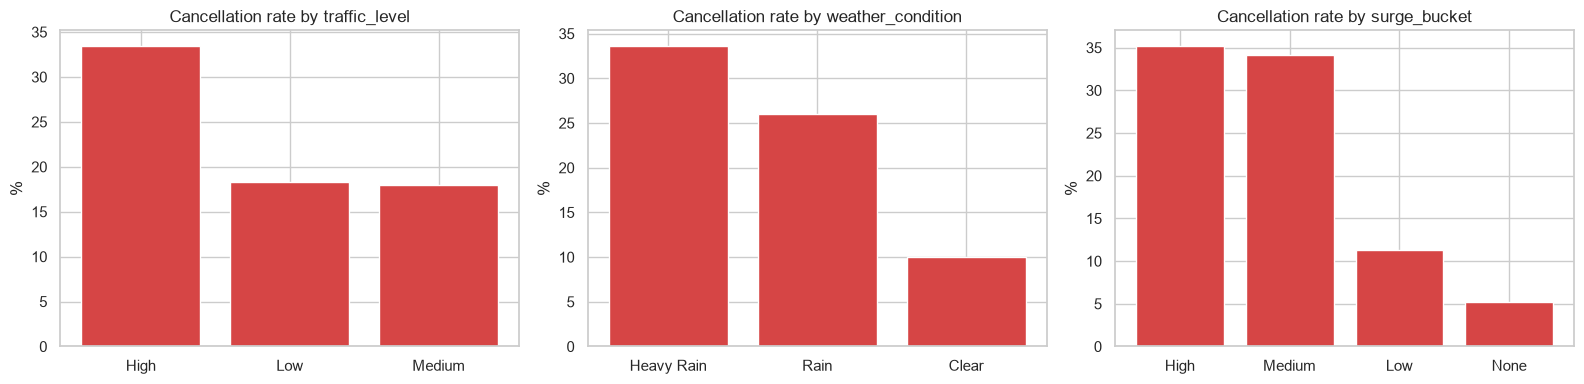

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, column in zip(axes, ["traffic_level", "weather_condition", "surge_bucket"]):
    rates = stats.cancellation_rate_by(df, column)
    ax.bar(rates[column].astype(str), rates["cancel_rate"], color="#D64545")
    ax.set_title(f"Cancellation rate by {column}")
    ax.set_ylabel("%")
plt.tight_layout()
plt.show()

**Key finding.** Traffic, weather and surge move the cancellation rate by 15-30
percentage points. City and vehicle type move it by less than one point. The two
failure modes are also distinct: weather drives *cancellations* but leaves the
*incompletion* rate flat, while traffic drives both.

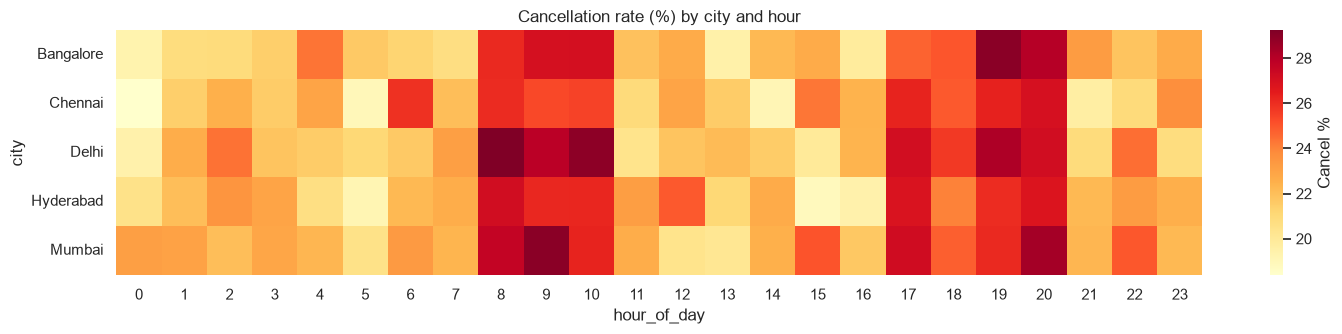

In [14]:
pivot = df.assign(
    cancelled=(df["booking_status"].astype(str) == "Cancelled").astype(int)
).pivot_table(index="city", columns="hour_of_day", values="cancelled", aggfunc="mean") * 100

fig, ax = plt.subplots(figsize=(15, 3.5))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Cancel %"})
ax.set_title("Cancellation rate (%) by city and hour")
plt.tight_layout()
plt.show()

## 6. Multivariate Analysis

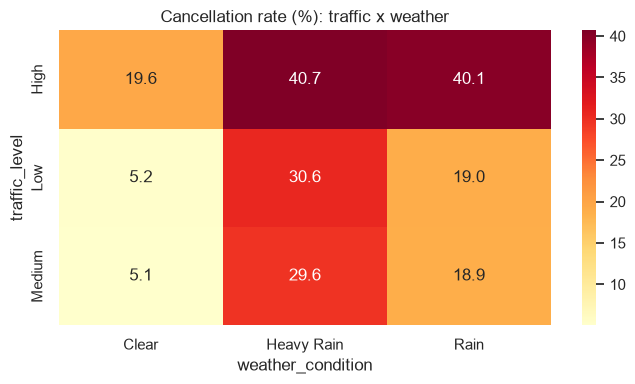

In [15]:
combo = df.assign(
    cancelled=(df["booking_status"].astype(str) == "Cancelled").astype(int)
).pivot_table(
    index="traffic_level", columns="weather_condition", values="cancelled", aggfunc="mean"
) * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(combo, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Cancellation rate (%): traffic x weather")
plt.tight_layout()
plt.show()

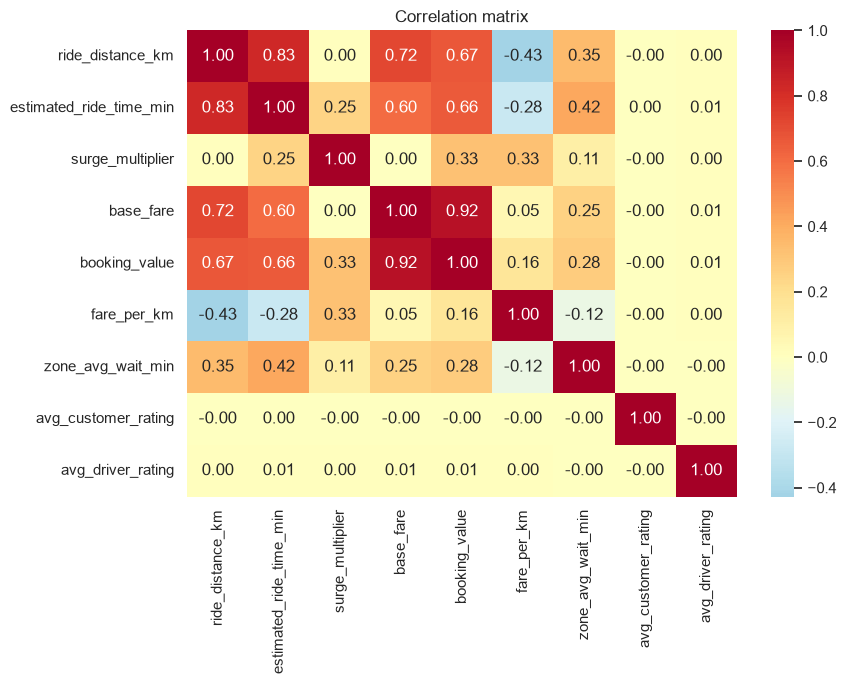

In [16]:
numeric_columns = ["ride_distance_km", "estimated_ride_time_min", "surge_multiplier",
                   "base_fare", "booking_value", "fare_per_km", "zone_avg_wait_min",
                   "avg_customer_rating", "avg_driver_rating"]
correlations = stats.correlation_matrix(df, numeric_columns)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

## 7. Statistical Significance

**Test choices.**

- *Chi-square test of independence* for categorical driver vs categorical outcome:
  the question is association, not a difference of means.
- *One-way ANOVA* for fare across three vehicle types: compares all group means in
  one test instead of three t-tests, avoiding inflated family-wise error.
- *Welch's t-test* for weekend vs weekday fare: two groups, and it does not assume
  equal variances.
- *Cramer's V* alongside every chi-square, because at n = 100,000 p-values collapse
  toward zero and effect size is what actually separates a real driver from a
  trivial one.

In [17]:
results = stats.run_standard_tests(df)
stats.summarise_tests(results)

,test,variables,statistic,p_value,effect_size,conclusion
0,Chi-square test of independence,traffic_level vs booking_status,6869.6246,< 0.0001,0.1853,significant (reject H0)
1,Chi-square test of independence,weather_condition vs booking_status,5622.0518,< 0.0001,0.1677,significant (reject H0)
2,Chi-square test of independence,vehicle_type vs booking_status,2.2017,0.6987,0.0033,not significant (retain H0)
3,Chi-square test of independence,city vs booking_status,8.3752,0.3977,0.0065,not significant (retain H0)
4,One-way ANOVA,booking_value across vehicle_type,27763.2822,< 0.0001,-,significant (reject H0)
5,One-way ANOVA,surge_multiplier across traffic_level,17148.8523,< 0.0001,-,significant (reject H0)
6,Welch's two-sample t-test,booking_value by weekend_label,-0.1030,0.9179,-0.0007,not significant (retain H0)


## 8. Fare Structure

In [18]:
for vehicle, group in df.groupby("vehicle_type", observed=True):
    slope, intercept = np.polyfit(group["ride_distance_km"], group["base_fare"], 1)
    predicted = slope * group["ride_distance_km"] + intercept
    ss_res = ((group["base_fare"] - predicted) ** 2).sum()
    ss_tot = ((group["base_fare"] - group["base_fare"].mean()) ** 2).sum()
    print(f"{vehicle:5s}  base_fare = {intercept:6.2f} + {slope:5.2f} * km   "
          f"R2 = {1 - ss_res / ss_tot:.6f}")

Auto   base_fare =  40.00 + 12.00 * km   R2 = 1.000000
Bike   base_fare =  20.00 +  8.00 * km   R2 = 1.000000
Cab    base_fare =  80.00 + 18.00 * km   R2 = 1.000000


The tariff is exact: Bike ₹20 + ₹8/km, Auto ₹40 + ₹12/km, Cab ₹80 + ₹18/km.

Since `booking_value = base_fare x surge x (1 ± 5% uniform)`, and a uniform variable
on [0.95, 1.05] has mean absolute deviation 2.5%, **no model can achieve better than
2.50% MAPE**. The trained model reaches 2.76% - essentially the noise floor.

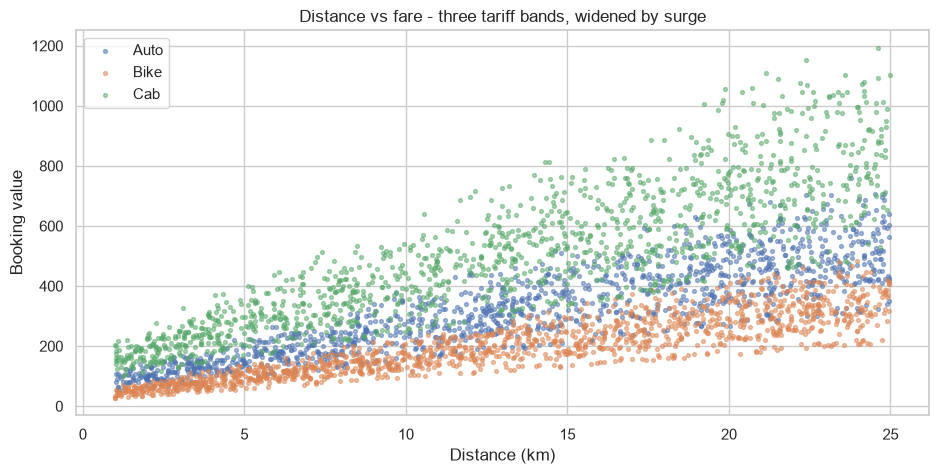

In [19]:
sample = df.sample(4000, random_state=42)
fig, ax = plt.subplots(figsize=(11, 5))
for vehicle, group in sample.groupby("vehicle_type", observed=True):
    ax.scatter(group["ride_distance_km"], group["booking_value"], s=8, alpha=0.5, label=vehicle)
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Booking value")
ax.set_title("Distance vs fare - three tariff bands, widened by surge")
ax.legend()
plt.show()

## 9. Feature Engineering

Engineered features fall into two groups.

**Context features** come from the booking row: `rush_hour_flag`, `long_distance_flag`,
`city_route_pair`, `expected_speed_kmph`, `surge_bucket`, `adverse_conditions_flag`,
`fare_per_km`, `fare_per_min`.

**History features** describe the customer or driver and are built as *prior* history:
an expanding window over strictly earlier bookings, so a booking never contributes to
its own predictors. The static `cancellation_rate` and `delay_rate` columns are
whole-period aggregates that already include the row being predicted, so they are
replaced rather than used.

The proof is in the null counts below: exactly one null per customer and per driver -
their first-ever ride, which has no prior history.

In [20]:
history_columns = [c for c in df.columns if c.startswith(("cust_prior", "drv_prior"))]
print(df[history_columns].isna().sum())
print()
print(f"Customers: {df['customer_id'].nunique():,}   Drivers: {df['driver_id'].nunique():,}")

cust_prior_rides                  0
cust_prior_cancelled              0
cust_prior_incomplete             0
cust_prior_cancel_rate        10000
cust_prior_incomplete_rate    10000
cust_prior_completion_rate    10000
drv_prior_rides                   0
drv_prior_cancelled               0
drv_prior_incomplete              0
drv_prior_cancel_rate          5000
drv_prior_incomplete_rate      5000
drv_prior_completion_rate      5000
dtype: int64

Customers: 10,000   Drivers: 5,000


In [21]:
df.groupby(pd.cut(df["cust_prior_cancel_rate"], bins=[0, .1, .2, .3, .5, 1.0]),
           observed=True).apply(
    lambda g: pd.Series({
        "bookings": len(g),
        "actual_cancel_rate": 100 * (g["booking_status"].astype(str) == "Cancelled").mean(),
    })
)

,bookings,actual_cancel_rate
cust_prior_cancel_rate,,
"(0.0, 0.1]",2096.0,23.902672
"(0.1, 0.2]",16214.0,23.547551
"(0.2, 0.3]",13521.0,23.215738
"(0.3, 0.5]",22687.0,23.193900
"(0.5, 1.0]",6643.0,23.287671


## 10. Conclusions

### Findings

1. **Conditions drive outcomes, not geography.** High traffic lifts cancellations to
   33.5% (vs ~18%), heavy rain to 33.7% (vs 10.0%). City and vehicle type are not
   statistically significant.
2. **Surge is the strongest single lever.** Cancellations rise from 5.3% at no surge
   to 35.3% above 2.0x - and surge is platform-controlled.
3. **Two distinct failure modes.** Weather drives cancellations but not incompletions;
   traffic drives both. Rider-side and driver-side interventions differ.
4. **Fare is a solved formula**, recovered exactly. The pre-quote model operates at
   the theoretical noise floor.

### Business recommendations

- Cap surge during heavy rain and high traffic, where risk compounds.
- Allocate drivers on live traffic and zone demand rather than city targets.
- Score bookings before dispatch with the cancellation model (ROC-AUC 0.851) and hold
  driver assignment on high-risk requests.
- Route reliable drivers to high-traffic windows: Driver Delay is the largest single
  incomplete-ride reason.

### Next steps

`scripts/manage.py train` trains the four models on this feature table; `app.py` serves
the dashboard and live predictions.